<a href="https://colab.research.google.com/github/dikshit-neupane/Share-Price-prediction/blob/main/Eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/nepse_full_market.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print("Shape:", df.shape)
print("Dtypes:\n", df.dtypes)
print(df.head())

Shape: (161639, 9)
Dtypes:
 date          datetime64[ns]
open                 float64
high                 float64
low                  float64
close                float64
pct_change           float64
volume               float64
turnover             float64
symbol                object
dtype: object
        date    open    high     low   close  pct_change  volume   turnover  \
0 2021-01-10   752.0   811.0   752.0   811.0        9.89   635.0   513385.0   
1 2021-01-11   827.0   892.0   827.0   892.0        9.99   380.0   336520.0   
2 2021-01-12   909.0   981.0   909.0   981.0        9.98   406.0   396486.0   
3 2021-01-13  1030.0  1079.0  1030.0  1079.0        9.99  6886.0  7424348.0   
4 2021-01-17  1132.0  1186.0  1132.0  1186.0        9.92  3217.0  3805112.0   

   symbol  
0  ACLBSL  
1  ACLBSL  
2  ACLBSL  
3  ACLBSL  
4  ACLBSL  


In [6]:
dupes = df.duplicated(subset=['symbol', 'date']).sum()
print("Duplicate (symbol, date) rows found:", dupes)

Duplicate (symbol, date) rows found: 0


In [8]:
df = df.drop_duplicates(subset=['symbol', 'date'], keep='first').reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (161639, 9)


In [9]:
invalid_prices = df[(df['open'] <= 0) | (df['high'] <= 0) | (df['low'] <= 0) | (df['close'] <= 0)]
print("Rows with non-positive prices:", len(invalid_prices))

print("Negative volume rows:", (df['volume'] < 0).sum())
print("Negative turnover rows:", (df['turnover'] < 0).sum())

Rows with non-positive prices: 0
Negative volume rows: 0
Negative turnover rows: 0


In [10]:
df = df[
    (df['open'] > 0) & (df['high'] > 0) &
    (df['low'] > 0) & (df['close'] > 0) &
    (df['volume'] >= 0) & (df['turnover'] >= 0)
].reset_index(drop=True)

print("Shape after removing invalid rows:", df.shape)

Shape after removing invalid rows: (161638, 9)


In [11]:
bad_ohlc = df[
    (df['low'] > df['open']) | (df['low'] > df['close']) |
    (df['low'] > df['high']) | (df['high'] < df['open']) |
    (df['high'] < df['close'])
]
print("OHLC inconsistent rows:", len(bad_ohlc))

OHLC inconsistent rows: 520


In [12]:
ohlc_cols = ['open', 'high', 'low', 'close']
df['high'] = df[ohlc_cols].max(axis=1)
df['low']  = df[ohlc_cols].min(axis=1)

print("Shape after OHLC fix:", df.shape)

Shape after OHLC fix: (161638, 9)


In [13]:
bad_ohlc = df[
    (df['low'] > df['open']) | (df['low'] > df['close']) |
    (df['low'] > df['high']) | (df['high'] < df['open']) |
    (df['high'] < df['close'])
]
print("OHLC inconsistent rows:", len(bad_ohlc))

OHLC inconsistent rows: 0


In [14]:
counts = df.groupby('symbol').size()
print("Symbol count distribution:\n", counts.describe())

valid_symbols = counts[counts >= 100].index
df = df[df['symbol'].isin(valid_symbols)].reset_index(drop=True)

print("Symbols remaining:", df['symbol'].nunique())
print("Rows remaining:", df.shape[0])

Symbol count distribution:
 count     263.000000
mean      614.593156
std       486.444192
min         1.000000
25%       131.500000
50%       596.000000
75%      1207.000000
max      1262.000000
dtype: float64
Symbols remaining: 206
Rows remaining: 160212


In [15]:
counts = df.groupby('symbol').size()
print("Symbols with >1000 rows:", (counts > 1000).sum())
valid_symbols = counts[counts > 1000].index
df = df[df['symbol'].isin(valid_symbols)].reset_index(drop=True)
print("Symbols remaining:", df['symbol'].nunique())
print("Rows remaining:", df.shape[0])
print(df.groupby('symbol').size().sort_values(ascending=False))

Symbols with >1000 rows: 80
Symbols remaining: 80
Rows remaining: 98866
symbol
AKJCL     1262
API       1262
BARUN     1262
EBL       1262
CHL       1262
          ... 
NIBSF2    1139
GBIME     1118
MKJC      1084
MLBS      1069
BNHC      1010
Length: 80, dtype: int64


In [16]:
df['date_diff'] = df.groupby('symbol')['date'].diff().dt.days

gap_summary = df[df['date_diff'] > 30].groupby('symbol').size().sort_values(ascending=False)
print("Symbols with gaps >30 days:", len(gap_summary))
print(gap_summary.head(20))

Symbols with gaps >30 days: 8
symbol
GBIME    2
SKBBL    2
GBLBS    1
BBC      1
KBL      1
PRIN     1
RBCL     1
SLBSL    1
dtype: int64


In [17]:
df = df.drop(columns=['date_diff'])

In [19]:
df['date_diff'] = df.groupby('symbol')['date'].diff().dt.days

gap_summary = df[df['date_diff'] > 30].groupby('symbol').size().sort_values(ascending=False)
print("Symbols with gaps >30 days:", len(gap_summary))
print(gap_summary.head(20))
df = df.drop(columns=['date_diff'])

Symbols with gaps >30 days: 8
symbol
GBIME    2
SKBBL    2
GBLBS    1
BBC      1
KBL      1
PRIN     1
RBCL     1
SLBSL    1
dtype: int64


In [20]:
df['pct_change_calc'] = df.groupby('symbol')['close'].pct_change() * 100
df['pct_diff'] = (df['pct_change'] - df['pct_change_calc']).abs()

mismatches = df[df['pct_diff'] > 5]
print("Rows with large pct_change mismatch (>5%):", len(mismatches))
print(mismatches[['symbol','date','close','pct_change','pct_change_calc']].head(10))

df['split_flag'] = (df['pct_diff'] > 5).astype(int)
print("Total flagged rows:", df['split_flag'].sum())

df = df.drop(columns=['pct_change_calc', 'pct_diff'])

Rows with large pct_change mismatch (>5%): 177
      symbol       date    close  pct_change  pct_change_calc
54    ACLBSL 2021-03-31  1576.00        2.94        -5.458908
293   ACLBSL 2022-03-31  1101.10       -0.62       -17.582335
2091   AKJCL 2024-07-16   162.80       10.00       -26.000000
2603     API 2021-05-12   314.00        6.08       -11.048159
2680     API 2021-09-05   433.00       -9.55       -18.147448
2811     API 2022-03-28   368.00        1.30       -21.182266
3026     API 2023-02-16   264.00       -0.77        -7.692308
3118     API 2023-07-09   197.00        2.53       -13.973799
4151   BARUN 2022-07-18   298.60        9.98       -32.595937
4816   BARUN 2025-06-05   319.28        9.96       -33.582959
Total flagged rows: 177


In [21]:
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print("Final cleaned shape:", df.shape)
print(df.dtypes)
print(df.head())

# Save so you don't rerun cleaning every session
df.to_csv('nepse_cleaned.csv', index=False)
print("Saved to nepse_cleaned.csv")

Final cleaned shape: (98866, 10)
date          datetime64[ns]
open                 float64
high                 float64
low                  float64
close                float64
pct_change           float64
volume               float64
turnover             float64
symbol                object
split_flag             int64
dtype: object
        date    open    high     low   close  pct_change  volume   turnover  \
0 2021-01-10   752.0   811.0   752.0   811.0        9.89   635.0   513385.0   
1 2021-01-11   827.0   892.0   827.0   892.0        9.99   380.0   336520.0   
2 2021-01-12   909.0   981.0   909.0   981.0        9.98   406.0   396486.0   
3 2021-01-13  1030.0  1079.0  1030.0  1079.0        9.99  6886.0  7424348.0   
4 2021-01-17  1132.0  1186.0  1132.0  1186.0        9.92  3217.0  3805112.0   

   symbol  split_flag  
0  ACLBSL           0  
1  ACLBSL           0  
2  ACLBSL           0  
3  ACLBSL           0  
4  ACLBSL           0  
Saved to nepse_cleaned.csv


# EDA


In [22]:
print(df.describe())
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("Number of symbols:", df['symbol'].nunique())
print("Avg rows per symbol:", round(df.groupby('symbol').size().mean(), 1))

                                date          open          high  \
count                          98866  98866.000000  98866.000000   
mean   2023-09-14 05:24:05.374547456   1261.716010   1280.566926   
min              2021-01-03 00:00:00      6.710000      6.900000   
25%              2022-05-18 00:00:00    258.025000    264.000000   
50%              2023-08-30 00:00:00    451.200000    462.000000   
75%              2025-01-19 00:00:00    800.000000    813.775000   
max              2026-06-05 00:00:00  55080.000000  56805.800000   
std                              NaN   4196.766539   4236.327893   

                low         close    pct_change        volume      turnover  \
count  98866.000000  98866.000000  98866.000000  9.886600e+04  9.886600e+04   
mean    1242.147679   1259.659430      0.094555  6.196392e+04  2.499090e+07   
min        6.600000      6.790000    -12.400000  1.000000e+00  4.380000e+02   
25%      252.625000    258.000000     -1.390000  5.179000e+03  2.285102

In [23]:
date_ranges = df.groupby('symbol')['date'].agg(['min', 'max', 'count'])
print(date_ranges.describe())
print("\nSymbols with shortest history:")
print(date_ranges.sort_values('count').head(10))

                       min                  max        count
count                   80                   80    80.000000
mean   2021-01-26 00:00:00  2026-06-05 00:00:00  1235.825000
min    2021-01-03 00:00:00  2026-06-05 00:00:00  1010.000000
25%    2021-01-03 00:00:00  2026-06-05 00:00:00  1229.250000
50%    2021-01-03 00:00:00  2026-06-05 00:00:00  1262.000000
75%    2021-01-03 00:00:00  2026-06-05 00:00:00  1262.000000
max    2022-01-18 00:00:00  2026-06-05 00:00:00  1262.000000
std                    NaN                  NaN    50.420203

Symbols with shortest history:
              min        max  count
symbol                             
BNHC   2022-01-18 2026-06-05   1010
MLBS   2021-10-06 2026-06-05   1069
MKJC   2021-09-22 2026-06-05   1084
GBIME  2021-01-03 2026-06-05   1118
NIBSF2 2021-06-27 2026-06-05   1139
PSF    2021-06-22 2026-06-05   1144
SBCF   2021-06-09 2026-06-05   1148
UNL    2021-01-03 2026-06-05   1158
PRIN   2021-01-03 2026-06-05   1170
SMATA  2021-05-04 2026-

In [24]:
activity = df.groupby('symbol').agg(
    avg_volume=('volume', 'mean'),
    avg_turnover=('turnover', 'mean'),
    avg_close=('close', 'mean'),
    days=('date', 'count')
).sort_values('avg_turnover', ascending=False)

print("Top 10 most active symbols by turnover:")
print(activity.head(10))

print("\nBottom 10 least active symbols by turnover:")
print(activity.tail(10))

Top 10 most active symbols by turnover:
           avg_volume  avg_turnover    avg_close  days
symbol                                                
NGPL    231478.282092  9.463943e+07   388.566490  1262
HDL      39494.493661  8.626460e+07  2702.963019  1262
API     253972.339144  8.536645e+07   294.041157  1262
NIFRA   212410.982157  7.183381e+07   285.526910  1233
NHPC    238890.890650  6.546516e+07   231.636157  1262
SHPC    129305.004754  6.531967e+07   422.925792  1262
HIDCL   205016.040412  6.373635e+07   261.919501  1262
UPPER   173629.599842  6.331329e+07   379.021339  1262
KBL     246178.172951  5.726005e+07   216.703566  1220
UMHL    125489.603803  5.150338e+07   348.452456  1262

Bottom 10 least active symbols by turnover:
           avg_volume  avg_turnover     avg_close  days
symbol                                                 
BBC        748.159167  3.862909e+06   4500.371208  1200
MLBS      2093.521048  3.349651e+06   1267.686838  1069
UNL         93.570812  3.050676

In [25]:
volatility = df.groupby('symbol')['pct_change'].std().sort_values(ascending=False)

print("Top 10 most volatile symbols:")
print(volatility.head(10))

print("\nBottom 10 least volatile symbols:")
print(volatility.tail(10))

Top 10 most volatile symbols:
symbol
NFS      3.585288
JOSHI    3.519148
SFCL     3.482147
HPPL     3.441297
SINDU    3.423193
GLBSL    3.403028
KKHC     3.394926
GHL      3.387949
PMHPL    3.348657
JFL      3.341440
Name: pct_change, dtype: float64

Bottom 10 least volatile symbols:
symbol
SICL      1.905658
NIBSF2    1.901839
NBF2      1.881531
GBIME     1.845351
NICBF     1.820848
KEF       1.803010
SKBBL     1.715462
NMB       1.645848
PSF       1.626779
EBL       1.534131
Name: pct_change, dtype: float64


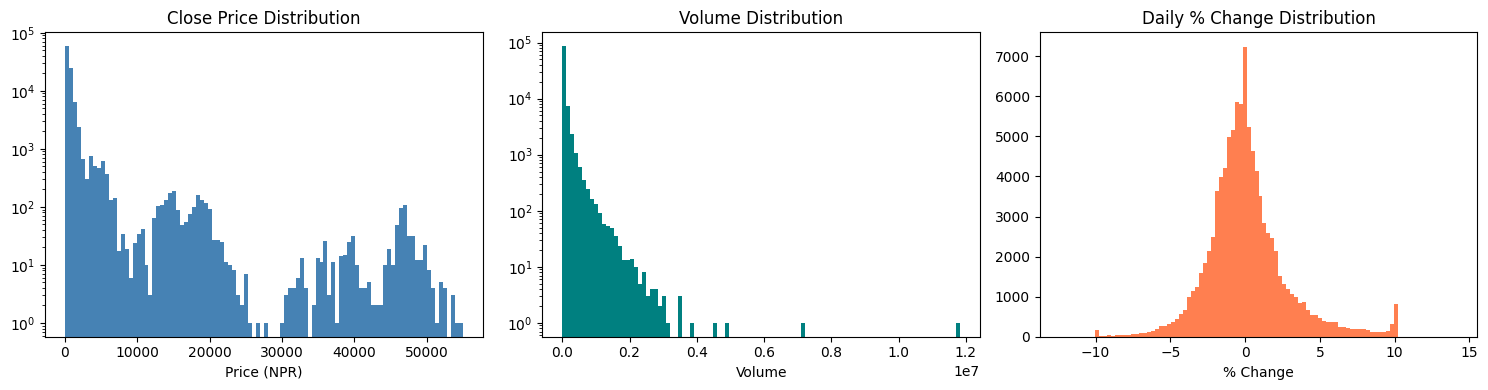

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['close'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Close Price Distribution')
axes[0].set_xlabel('Price (NPR)')
axes[0].set_yscale('log')

axes[1].hist(df['volume'], bins=100, color='teal', edgecolor='none')
axes[1].set_title('Volume Distribution')
axes[1].set_xlabel('Volume')
axes[1].set_yscale('log')

axes[2].hist(df['pct_change'], bins=100, color='coral', edgecolor='none')
axes[2].set_title('Daily % Change Distribution')
axes[2].set_xlabel('% Change')

plt.tight_layout()
plt.show()

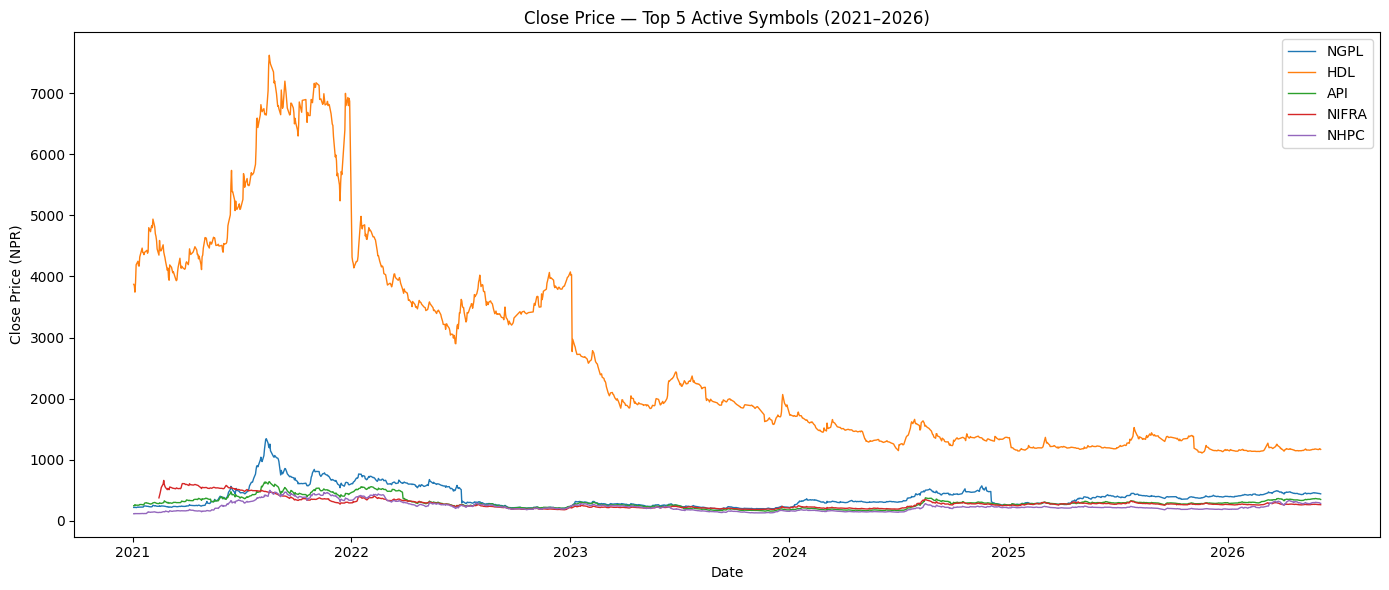

In [27]:
top5 = activity.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for sym in top5:
    sub = df[df['symbol'] == sym]
    ax.plot(sub['date'], sub['close'], label=sym, linewidth=1)

ax.set_title('Close Price — Top 5 Active Symbols (2021–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (NPR)')
ax.legend()
plt.tight_layout()
plt.show()

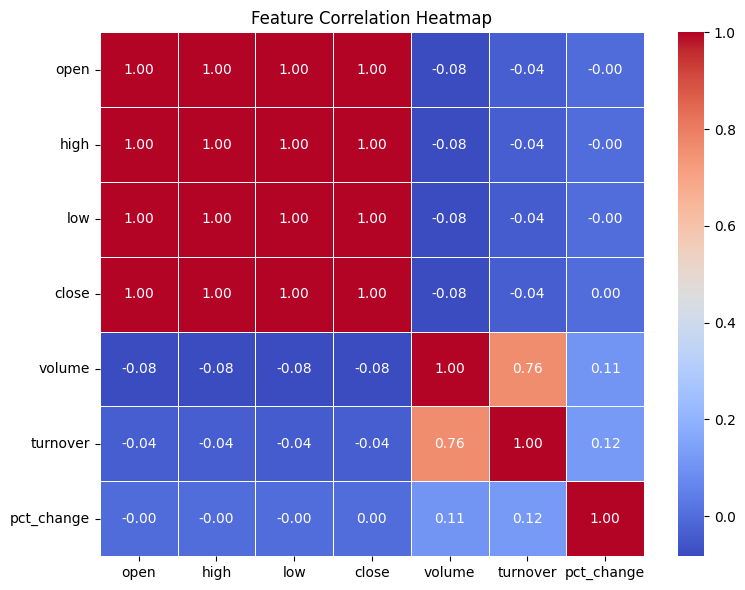

In [28]:
corr = df[['open','high','low','close','volume','turnover','pct_change']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

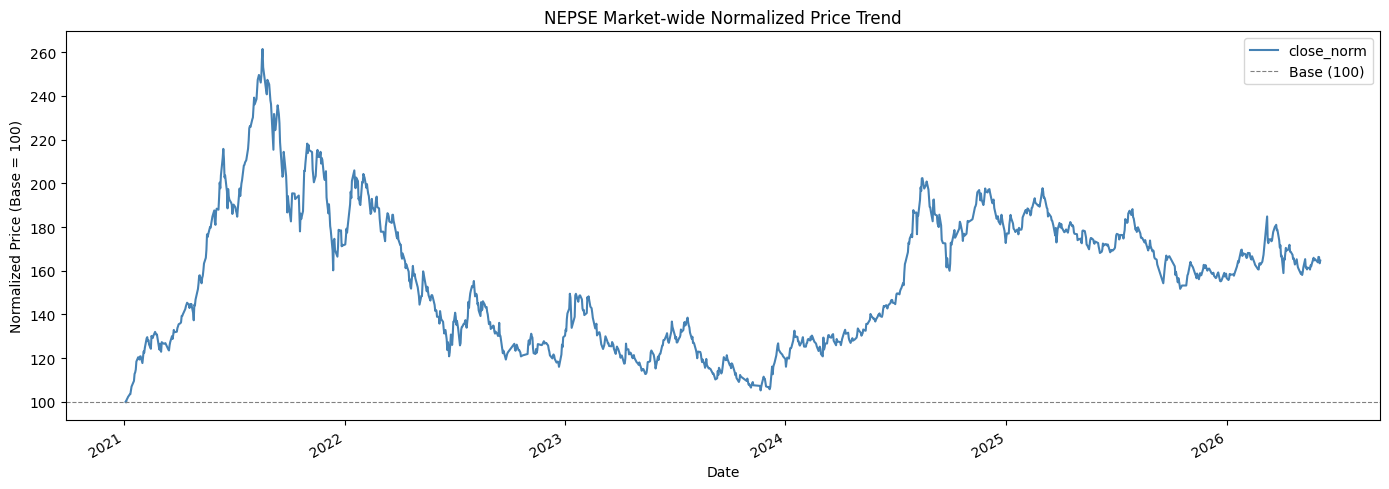

In [29]:
df['close_norm'] = df.groupby('symbol')['close'].transform(
    lambda x: x / x.iloc[0] * 100
)
market_trend = df.groupby('date')['close_norm'].mean()

plt.figure(figsize=(14, 5))
market_trend.plot(color='steelblue', linewidth=1.5)
plt.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='Base (100)')
plt.title('NEPSE Market-wide Normalized Price Trend')
plt.ylabel('Normalized Price (Base = 100)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# Drop helper column after use
df = df.drop(columns=['close_norm'])

In [30]:
print("Min pct_change:", df['pct_change'].min())
print("Max pct_change:", df['pct_change'].max())
print("Rows with |pct_change| > 10:", (df['pct_change'].abs() > 10).sum())
print("Split-flagged rows:", df['split_flag'].sum())

extreme = df[df['pct_change'].abs() > 10]
print(extreme[['symbol','date','close','pct_change','split_flag']].head(10))

Min pct_change: -12.4
Max pct_change: 14.19
Rows with |pct_change| > 10: 5
Split-flagged rows: 177
      symbol       date   close  pct_change  split_flag
12280  FMDBL 2026-05-11  919.00       14.19           0
12281  FMDBL 2026-05-12  805.00      -12.40           0
33999    KEF 2023-07-20    9.13      -10.05           0
34254    KEF 2024-09-04    9.62      -10.09           0
92661  SWBBL 2026-05-07  810.00       12.19           0


In [31]:
# Inspect these 5 rows more closely
extreme = df[df['pct_change'].abs() > 10]
print(extreme[['symbol','date','open','high','low','close','pct_change','split_flag']])

# Check the surrounding rows for context
for sym in extreme['symbol'].unique():
    sub = df[df['symbol'] == sym].copy()
    idx = sub[sub['pct_change'].abs() > 10].index
    for i in idx:
        print(f"\n--- {sym} around index {i} ---")
        print(sub.loc[max(0,i-3):i+3, ['date','open','high','low','close','pct_change','split_flag']])

      symbol       date    open    high     low   close  pct_change  \
12280  FMDBL 2026-05-11  810.00  925.00  804.00  919.00       14.19   
12281  FMDBL 2026-05-12  874.00  874.00  790.00  805.00      -12.40   
33999    KEF 2023-07-20    9.95    9.95    9.13    9.13      -10.05   
34254    KEF 2024-09-04   10.49   10.49    9.62    9.62      -10.09   
92661  SWBBL 2026-05-07  722.00  810.00  720.00  810.00       12.19   

       split_flag  
12280           0  
12281           0  
33999           0  
34254           0  
92661           0  

--- FMDBL around index 12280 ---
            date   open   high    low  close  pct_change  split_flag
12277 2026-05-06  795.0  820.9  780.0  780.0       -1.02           0
12278 2026-05-07  760.0  807.0  760.0  800.0        2.56           0
12279 2026-05-08  796.0  806.0  796.0  804.8        0.60           0
12280 2026-05-11  810.0  925.0  804.0  919.0       14.19           0
12281 2026-05-12  874.0  874.0  790.0  805.0      -12.40           0
12282

In [32]:
kef = df[df['symbol'] == 'KEF'].copy()
print(kef[['date','close','volume','pct_change']].describe())
print(kef[['date','close','volume','pct_change']].tail(20))

                                date        close        volume   pct_change
count                           1184  1184.000000  1.184000e+03  1184.000000
mean   2023-10-25 12:12:09.729729792     8.993944  3.553474e+04     0.043539
min              2021-04-19 00:00:00     7.140000  1.000000e+02   -10.090000
25%              2022-07-07 18:00:00     8.320000  5.492500e+03    -0.980000
50%              2023-10-10 12:00:00     9.000000  1.310000e+04     0.000000
75%              2025-02-06 18:00:00     9.380000  3.154525e+04     0.860000
max              2026-06-05 00:00:00    11.340000  1.021460e+06     9.410000
std                              NaN     0.786482  8.339161e+04     1.803010
            date  close    volume  pct_change
34625 2026-05-07  10.64    2600.0        0.38
34626 2026-05-08  10.52   54200.0       -1.13
34627 2026-05-11  10.68   18285.0        1.52
34628 2026-05-12  10.70   11500.0        0.19
34629 2026-05-13  10.84    3100.0        1.31
34630 2026-05-14  10.65    6100